# Titanik Veri Seti İncelemesi ve Yarışma Tahmini
Bu not defterinde Titanik veri görselleştirme, kişisel veri analizi...

1. Kütüphanelerin Yüklenmesi

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#çıktı hücresindeki uyarıları kapatmak için
import warnings
warnings.filterwarnings('ignore')

2. Veri Setlerini Yükleme

In [3]:
df_train=pd.read_csv(r'/kaggle/input/titanic/train.csv')
df_test=pd.read_csv(r'/kaggle/input/titanic/test.csv')

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


3. Veri İnceleme & Önişleme
* Keşifsel Veri Analizi (EDA)
* Veri Görselleştirme
* Eksik verilerin işlenmesi
* Özellikleri belirleme ve dönüştürme
* Veri setinin (x-y) ayrılması (Feature-Target)
* Veri setinin eğitim-doğrulama-test olarak ayrılması

In [6]:
#veri setlerine bakalım info()
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
#eksik verilerin sayısını gösterir
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [9]:
#tanımlayıcı istatistikler: tüm özellikleri incele
df_train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [10]:
#kategorik özellikleri ve sayısal özellikleri belirleme
#df_train['Pclass']=df_train['Pclass'].cat.set_categories([3,2,1], ordered=True)
df_train['Pclass'].dtype

dtype('int64')

In [11]:
df_train['Sex']=df_train['Sex'].astype('category')
df_train['Sex'].dtype

CategoricalDtype(categories=['female', 'male'], ordered=False, categories_dtype=object)

In [12]:
df_train['Embarked']=df_train['Embarked'].astype('category')
df_train['Embarked'].dtype

CategoricalDtype(categories=['C', 'Q', 'S'], ordered=False, categories_dtype=object)

In [13]:
df_test.describe(include='all')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [14]:
#sayısal özellikler
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
#kategorik özellikler için betimsel istatistikler
df_train.describe(include=['object', 'category'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [16]:
#ölüm kalım sayısı
df_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [17]:
#ölüm kalım oransal değeri
df_train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

<Axes: ylabel='proportion'>

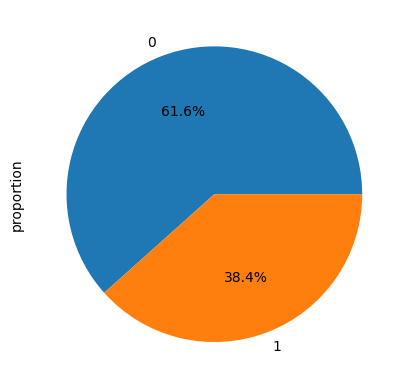

In [18]:
df_train['Survived'].value_counts(normalize=True).plot(kind='pie', autopct='%.1f%%')

Cinsiyete Göre Hayatta Kalma Durumları

In [19]:
df_train.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [20]:
#cinsiyete göre hayatta kalma durumu
df_train.groupby('Sex')['Survived'].value_counts(normalize=True)

Sex     Survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: proportion, dtype: float64

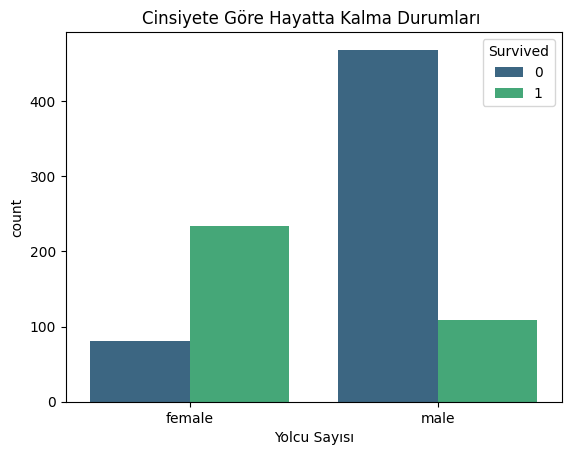

In [21]:
sns.countplot(data=df_train,
             x='Sex',
             hue='Survived',
             palette='viridis')
plt.title('Cinsiyete Göre Hayatta Kalma Durumları ')
plt.xlabel('Cinsiyet')
plt.xlabel('Yolcu Sayısı')
plt.show()

<Axes: title={'center': 'Erkekler Hayatta Kalma Oranı'}, ylabel='count'>

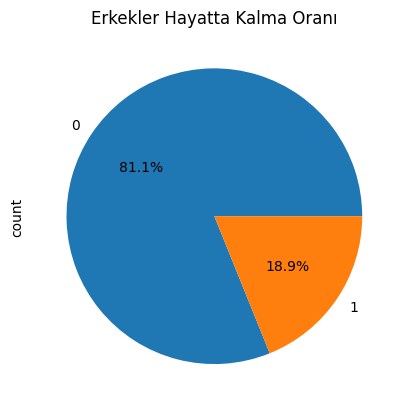

In [22]:
#sadece erkeklerin olduğu bir veri seti
df_train_male=df_train[df_train['Sex']=='male']
df_train_male['Survived'].value_counts().plot(kind='pie', 
                                              autopct='%1.1f%%', 
                                              title='Erkekler Hayatta Kalma Oranı')

<Axes: title={'center': 'Kadınlar Hayatta Kalma Oranı'}, ylabel='count'>

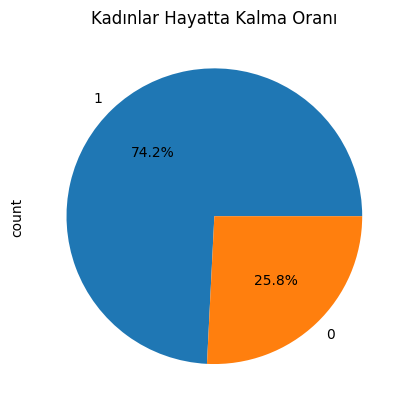

In [23]:
#sadece kadınların olduğu bir veri seti
df_train_female=df_train[df_train['Sex']=='female']
df_train_female['Survived'].value_counts().plot(kind='pie', 
                                                autopct='%1.1f%%', 
                                                title='Kadınlar Hayatta Kalma Oranı')

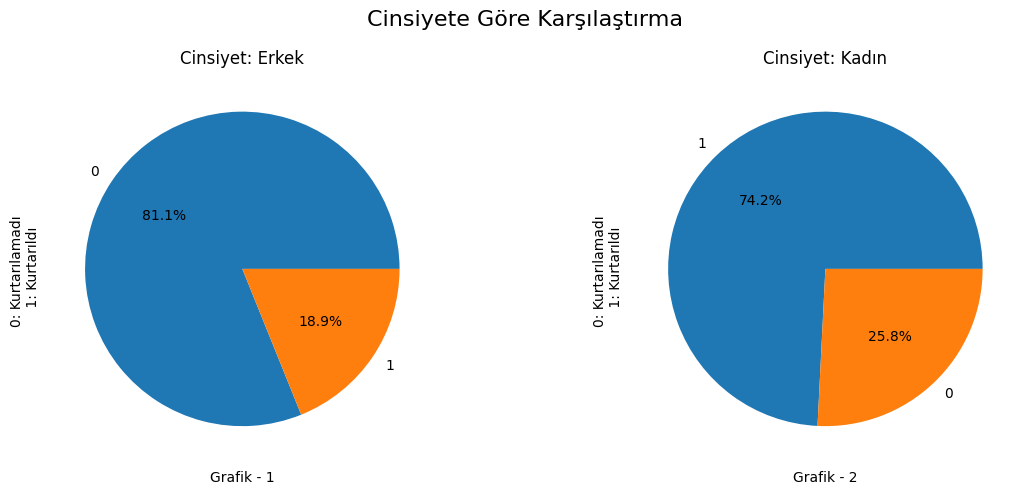

In [24]:
#cinsiyete göre karşılaştırmalı
fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('Cinsiyete Göre Karşılaştırma', fontsize=16) #grafik başlığı
for i, sex in enumerate(['male', 'female']):
    df_sex = df_train[df_train['Sex'] == sex]
    df_sex['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[i])
    sex_tr=['Erkek', 'Kadın'] #Türkçeye çevir
    axes[i].set_title(f'Cinsiyet: {sex_tr[i]}')
    axes[i].set_ylabel('0: Kurtarılamadı \n 1: Kurtarıldı')
    axes[i].set_xlabel(f'Grafik - {i+1}')
plt.tight_layout()
plt.show()

In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 71.7+ KB


### Yolculuk Sınıfına Göre Hayatta Kalma Durumu

In [26]:
df_train.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [27]:
df_train.groupby('Pclass')['Survived'].value_counts(normalize=True)

Pclass  Survived
1       1           0.629630
        0           0.370370
2       0           0.527174
        1           0.472826
3       0           0.757637
        1           0.242363
Name: proportion, dtype: float64

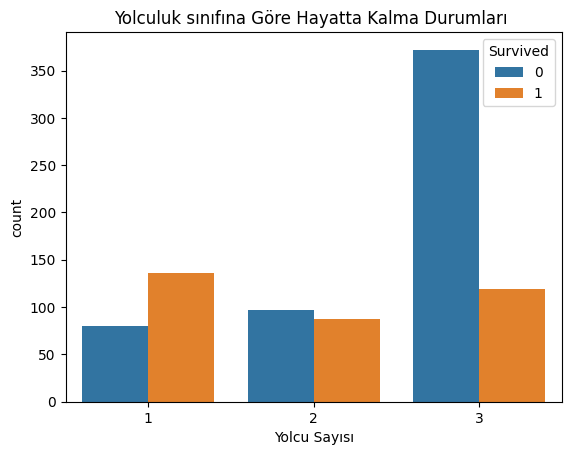

In [28]:
sns.countplot(data=df_train,
             x='Pclass',
             hue='Survived')
plt.title('Yolculuk sınıfına Göre Hayatta Kalma Durumları ')
plt.xlabel('PClass')
plt.xlabel('Yolcu Sayısı')
plt.show()

In [29]:
df_train['Pclass'].dtype

dtype('int64')

<Axes: title={'center': "P1'de Hayatta Kalma Oranı"}, ylabel='count'>

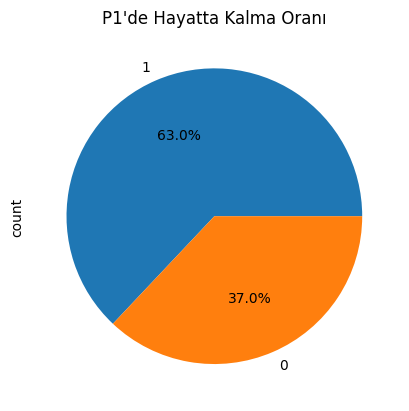

In [30]:
#sadece P1'lerin olduğu bir veri seti
df_train_pcalss1=df_train[df_train['Pclass']==1]
df_train_pcalss1['Survived'].value_counts().plot(kind='pie',
                                                autopct='%1.1f%%',
                                                title="P1'de Hayatta Kalma Oranı")

<Axes: title={'center': "P2'de Hayatta Kalma Oranı"}, ylabel='count'>

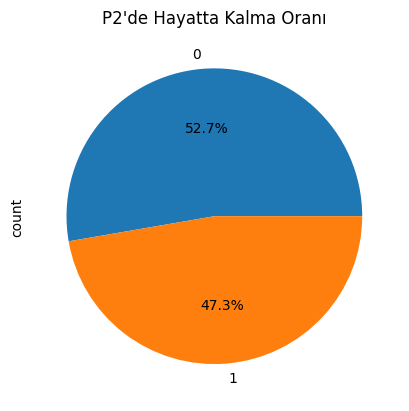

In [31]:
#sadece P2'lerin olduğu bir veri seti
df_train_pcalss2=df_train[df_train['Pclass']==2]
df_train_pcalss2['Survived'].value_counts().plot(kind='pie',
                                                autopct='%1.1f%%',
                                                title="P2'de Hayatta Kalma Oranı")

<Axes: title={'center': "P3'te Hayatta Kalma Oranı"}, ylabel='count'>

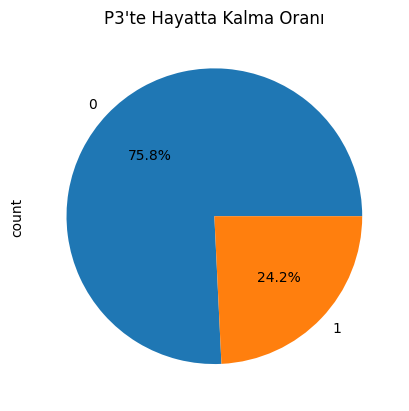

In [32]:
#sadece P3'lerin olduğu bir veri seti
df_train_pcalss3=df_train[df_train['Pclass']==3]
df_train_pcalss3['Survived'].value_counts().plot(kind='pie',
                                                autopct='%1.1f%%',
                                                title="P3'te Hayatta Kalma Oranı")

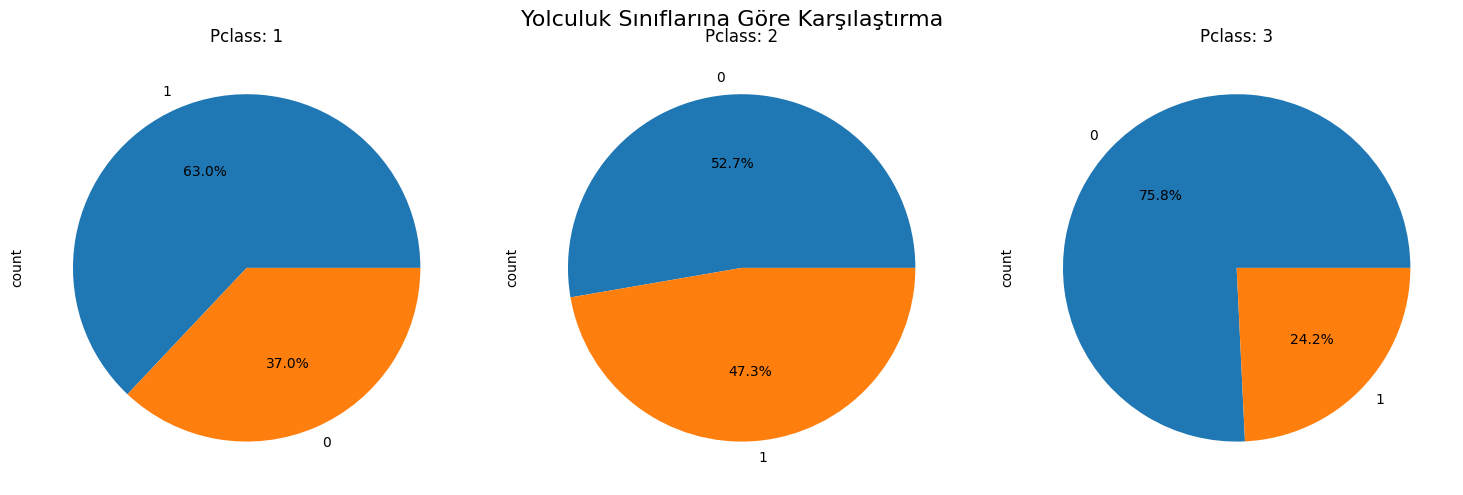

In [33]:
#yolculuk sınıflarının ek bir grafikle karşılaştırılması
fig,axes=plt.subplots(1, 3, figsize=(15,5)) #1 satır 3 sütun ve 15,5 büyüklüğünde alt grafikler oluşturur
fig.suptitle('Yolculuk Sınıflarına Göre Karşılaştırma', fontsize=16)
for i, pclass in enumerate([1,2,3]):
    df_pclass=df_train[df_train['Pclass']==pclass]
    df_pclass['Survived'].value_counts().plot(kind='pie',
                                                autopct='%1.1f%%',
                                                ax=axes[i])
    axes[i].set_title(f'Pclass: {pclass}')
plt.tight_layout()
plt.show()

### Yolculuk Sınıflarına Göre Cinsiyet Değişkeninin İncelenmesi

In [34]:
df_train.groupby(['Pclass','Sex'])['Survived'].value_counts()

Pclass  Sex     Survived
1       female  1            91
                0             3
        male    0            77
                1            45
2       female  1            70
                0             6
        male    0            91
                1            17
3       female  0            72
                1            72
        male    0           300
                1            47
Name: count, dtype: int64

In [35]:
df_train.groupby(['Pclass','Sex'])['Survived'].value_counts(normalize=True)

Pclass  Sex     Survived
1       female  1           0.968085
                0           0.031915
        male    0           0.631148
                1           0.368852
2       female  1           0.921053
                0           0.078947
        male    0           0.842593
                1           0.157407
3       female  0           0.500000
                1           0.500000
        male    0           0.864553
                1           0.135447
Name: proportion, dtype: float64

In [36]:
#P1'de hayatıunı kaybeden kadın yolcular
df_train[(df_train['Pclass']==1) & (df_train['Sex']=='female') & (df_train['Survived']==0)][['Name', 'Age']]

,Name,Age
177,"Isham, Miss. Ann Elizabeth",50.0
297,"Allison, Miss. Helen Loraine",2.0
498,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.0


In [37]:
#özel gruptaki kişi sayısı 
len(df_train[(df_train['Pclass']==1) & (df_train['Sex']=='female') & (df_train['Survived']==0)])

3

In [38]:
df_train[(df_train['Pclass']==1) & (df_train['Sex']=='female') & (df_train['Survived']==0)].value_counts().sum()

np.int64(3)

In [39]:
#isme göre arama
df_train[df_train['Name'].str.contains('Allison')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.55,C22 C26,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.55,C22 C26,S
498,499,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.55,C22 C26,S


In [40]:
#isme göre arama
#isim=input('Aranacak isim boşluk bırakmadan tek isim oalrak girin:')
#df_train[df_train['Name'].str.contains(isim, case=False)] # case sensiteve olmaz

In [41]:
#5 yaşın altında hayatını kaybeden yolcular
#df_train[df_train['Age']<=5].groupby('Pclass').value_counts()

In [42]:
#en yaşlı yolcunun yaşı
df_train['Age'].max()

80.0

In [43]:
df_train[df_train['Age']>=80]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S


In [44]:
#en yaşlı kişi(ler)
df_train[df_train['Age']==df_train['Age'].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S


In [45]:
#en küçük yolcu
df_train[df_train['Age']==df_train['Age'].min()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C


In [46]:
df_test[df_test['Age']==df_test['Age'].min()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
354,1246,3,"Dean, Miss. Elizabeth Gladys Millvina""""",female,0.17,1,2,C.A. 2315,20.575,NaN,S


In [47]:
#arama fonksiyonu tuple döndürür (aranan kişi var/yok, kaç kayıt var, df_list)
def arama(ad='Thomas'): # varsayılan parametre 
    """
    Örnek 1: Eşleşme varsa
    sonuc = arama('Allison')
    Çıktı: (True, 4, df ile Allison satırları)
    
    """
    sayac=len(df_train[df_train['Name'].str.contains(ad,case=False)])
    if sayac>0:
        return True,sayac,df_train[df_train['Name'].str.contains(ad,case=False)]  # tuple
    else: return False, sayac, False

In [48]:
help(arama)

Help on function arama in module __main__:

arama(ad='Thomas')
    Örnek 1: Eşleşme varsa
    sonuc = arama('Allison')
    Çıktı: (True, 4, df ile Allison satırları)



In [49]:
arama('thomas')[1] #kayıt sayısı

22

In [50]:
arama('thomas')[0] #olup olmadığı

True

In [51]:
arama('thomas')[2] #data frame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
149,150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.00,0,0,244310,13.0000,NaN,S
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.00,1,0,113776,66.6000,C2,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.5500,NaN,S
186,187,1,3,"O'Brien, Mrs. Thomas (Johanna ""Hannah"" Godfrey)",female,NaN,1,0,370365,15.5000,NaN,Q
252,253,0,1,"Stead, Mr. William Thomas",male,62.00,0,0,113514,26.5500,C87,S
260,261,0,3,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.7500,NaN,Q
336,337,0,1,"Pears, Mr. Thomas Clinton",male,29.00,1,0,113776,66.6000,C2,S
347,348,1,3,"Davison, Mrs. Thomas Henry (Mary E Finck)",female,NaN,1,0,386525,16.1000,NaN,S
364,365,0,3,"O'Brien, Mr. Thomas",male,NaN,1,0,370365,15.5000,NaN,Q
372,373,0,3,"Beavan, Mr. William Thomas",male,19.00,0,0,323951,8.0500,NaN,S


In [52]:
arama('betül')[2] # olup olmadığını

False

In [53]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 71.7+ KB


Text(0, 0.5, 'Sayı')

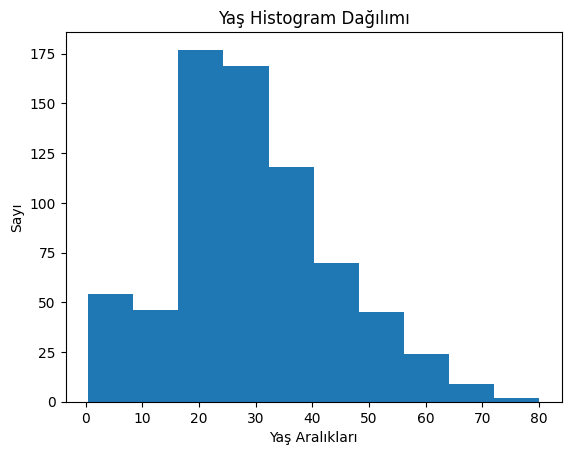

In [54]:
#yaş - histogram grafiği
df_train['Age'].plot(kind='hist', 
                     bins=10) #bins histogramın kaç gruptan oluşacağını belirler
plt.title("Yaş Histogram Dağılımı")
plt.xlabel("Yaş Aralıkları")
plt.ylabel("Sayı")

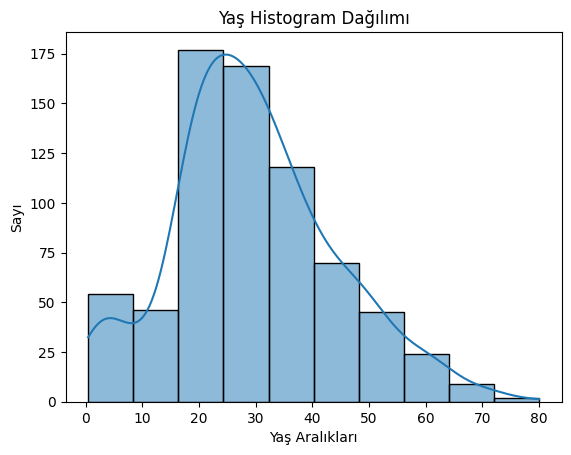

In [55]:
#seaborn yaş dağılım grafiği
sns.histplot(data=df_train,
            x='Age',
            bins=10,
            kde=True)

plt.title("Yaş Histogram Dağılımı")
plt.xlabel("Yaş Aralıkları")
plt.ylabel("Sayı")
plt.show()

In [56]:
arama('besim')

(False, 0, False)

In [57]:
len(df_test[df_test['Name'].str.contains('besim',case=False)])

0

In [58]:
#bilet ücretleri
df_train['Fare'].max(), df_train['Fare'].min(),df_train['Fare'].mean(), df_train['Fare'].median()

(512.3292, 0.0, np.float64(32.204207968574636), 14.4542)

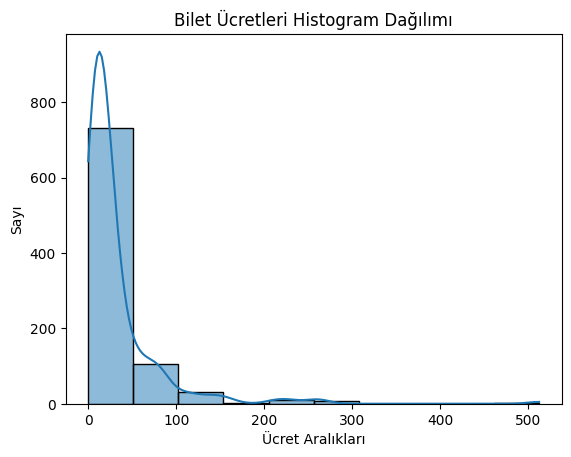

In [59]:
#seaborn bilet ücretleri grafiği
sns.histplot(data=df_train,
            x='Fare',
            bins=10,
            kde=True)

plt.title("Bilet Ücretleri Histogram Dağılımı")
plt.xlabel("Ücret Aralıkları")
plt.ylabel("Sayı")
plt.show()

In [60]:
# Pclass'lara göre Fare ortalamaları
df_train.groupby('Pclass')['Fare'].min(), df_train.groupby('Pclass')['Fare'].max(), df_train.groupby('Pclass')['Fare'].mean(),df_train.groupby('Pclass')['Fare'].median(),  

(Pclass
 1    0.0
 2    0.0
 3    0.0
 Name: Fare, dtype: float64,
 Pclass
 1    512.3292
 2     73.5000
 3     69.5500
 Name: Fare, dtype: float64,
 Pclass
 1    84.154687
 2    20.662183
 3    13.675550
 Name: Fare, dtype: float64,
 Pclass
 1    60.2875
 2    14.2500
 3     8.0500
 Name: Fare, dtype: float64)

In [61]:
df_train.groupby('Pclass')['Fare'].min()

Pclass
1    0.0
2    0.0
3    0.0
Name: Fare, dtype: float64

In [62]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 71.7+ KB


Sibsp: Siblings/Spouses Aboard - Gemideki kardeş/eş sayısı
Parch: Parent and Children Aboard - Gemideki ebeveyn/çocuk sayısı

In [63]:
#yalnız seyahat edenler
df_train_ylnz=df_train[(df_train['SibSp']==0) & (df_train['Parch']==0)]
len(df_train_ylnz)/len(df_train)

0.6026936026936027

In [64]:
#yalnız seyahat etmeyenler
df_train_notylnz=df_train[(df_train['SibSp']>0) | (df_train['Parch']>0)]
len(df_train_notylnz)/len(df_train)

0.39730639730639733

In [65]:
#yalnız eşiyle seyahat edenler (tahmini)
df_train_es=df_train[(df_train['SibSp']==1) & (df_train['Parch']==0) & (df_train['Age']>=18)]
len(df_train_es)/len(df_train)

0.10549943883277217

In [66]:
df_train_ylnz['Survived'].value_counts(normalize=True), df_train_notylnz['Survived'].value_counts(normalize=True), df_train['Survived'].value_counts(normalize=True)

(Survived
 0    0.696462
 1    0.303538
 Name: proportion, dtype: float64,
 Survived
 1    0.50565
 0    0.49435
 Name: proportion, dtype: float64,
 Survived
 0    0.616162
 1    0.383838
 Name: proportion, dtype: float64)

In [67]:
df_train_ylnz.groupby('Sex')['Survived'].value_counts(normalize=True), df_train_notylnz.groupby('Sex')['Survived'].value_counts(normalize=True)

(Sex     Survived
 female  1           0.785714
         0           0.214286
 male    0           0.844282
         1           0.155718
 Name: proportion, dtype: float64,
 Sex     Survived
 female  1           0.712766
         0           0.287234
 male    0           0.728916
         1           0.271084
 Name: proportion, dtype: float64)

In [68]:
df_train_es['Survived'].value_counts(normalize=True)

Survived
0    0.510638
1    0.489362
Name: proportion, dtype: float64

In [69]:
df_train.groupby('Parch')['Survived'].value_counts()

Parch  Survived
0      0           445
       1           233
1      1            65
       0            53
2      0            40
       1            40
3      1             3
       0             2
4      0             4
5      0             4
       1             1
6      0             1
Name: count, dtype: int64

In [70]:
df_train.groupby('Parch')['Survived'].value_counts(normalize=True)

Parch  Survived
0      0           0.656342
       1           0.343658
1      1           0.550847
       0           0.449153
2      0           0.500000
       1           0.500000
3      1           0.600000
       0           0.400000
4      0           1.000000
5      0           0.800000
       1           0.200000
6      0           1.000000
Name: proportion, dtype: float64

In [71]:
df_train[df_train['Age']<=12]['Survived'].value_counts(), df_train[df_train['Age']<=12]['Survived'].value_counts(normalize=True)

(Survived
 1    40
 0    29
 Name: count, dtype: int64,
 Survived
 1    0.57971
 0    0.42029
 Name: proportion, dtype: float64)

In [72]:
len(df_train) + len(df_test)

1309

In [73]:
#aile büyüklüğü
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch']
summary = df_train.groupby(['Pclass', 'FamilySize'])['Survived'].agg(['count', 'sum'])
summary['Died'] = summary['count'] - summary['sum']
summary['SurvivalRate'] = summary['sum'] / summary['count']
summary['TotalFamilies'] = summary['count']
print(summary[['TotalFamilies', 'Died', 'SurvivalRate']])

                   TotalFamilies  Died  SurvivalRate
Pclass FamilySize                                   
1      0                     109    51      0.532110
       1                      70    19      0.728571
       2                      24     6      0.750000
       3                       7     2      0.714286
       4                       2     0      1.000000
       5                       4     2      0.500000
2      0                     104    68      0.346154
       1                      34    16      0.529412
       2                      31    10      0.677419
       3                      13     3      0.769231
       4                       1     0      1.000000
       5                       1     0      1.000000
3      0                     324   255      0.212963
       1                      57    37      0.350877
       2                      47    27      0.425532
       3                       9     3      0.666667
       4                      12    12      0.

In [74]:
#isimlerin incelenmesi
df_train['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [75]:
#veri önişlemede işlemlerin satndart olması için train ve test datasetleri birleştirilir
df=pd.concat([df_train, df_test])
df['FamilySize'] = df['SibSp'] + df['Parch']
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0


In [76]:
len(df_train), len(df_test), len(df)

(891, 418, 1309)

In [77]:
#df indexinin sıfırlanması
df.reset_index(inplace=True)

In [78]:
df

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0
1305,414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0
1306,415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0
1307,416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        1309 non-null   int64  
 1   PassengerId  1309 non-null   int64  
 2   Survived     891 non-null    float64
 3   Pclass       1309 non-null   int64  
 4   Name         1309 non-null   object 
 5   Sex          1309 non-null   object 
 6   Age          1046 non-null   float64
 7   SibSp        1309 non-null   int64  
 8   Parch        1309 non-null   int64  
 9   Ticket       1309 non-null   object 
 10  Fare         1308 non-null   float64
 11  Cabin        295 non-null    object 
 12  Embarked     1307 non-null   object 
 13  FamilySize   1309 non-null   int64  
dtypes: float64(3), int64(6), object(5)
memory usage: 143.3+ KB


In [80]:
df['Cabin'].unique(),df['Cabin'].nunique()

(array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
        'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
        'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
        'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
        'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
        'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
        'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
        'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
        'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
        'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
        'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
        'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
        'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
        'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
   

In [81]:
df.isnull().sum()

index             0
PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
FamilySize        0
dtype: int64

In [82]:
df['Name']

0                                 Braund, Mr. Owen Harris
1       Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                  Heikkinen, Miss. Laina
3            Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                                Allen, Mr. William Henry
                              ...                        
1304                                   Spector, Mr. Woolf
1305                         Oliva y Ocana, Dona. Fermina
1306                         Saether, Mr. Simon Sivertsen
1307                                  Ware, Mr. Frederick
1308                             Peter, Master. Michael J
Name: Name, Length: 1309, dtype: object

In [83]:
df['Title']=df['Name'].str.extract('([A-Za-z]+)\.')
df['Title']

0           Mr
1          Mrs
2         Miss
3          Mrs
4           Mr
         ...  
1304        Mr
1305      Dona
1306        Mr
1307        Mr
1308    Master
Name: Title, Length: 1309, dtype: object

In [84]:
df['Title'].value_counts(), df['Title'].unique()

(Title
 Mr          757
 Miss        260
 Mrs         197
 Master       61
 Rev           8
 Dr            8
 Col           4
 Major         2
 Mlle          2
 Ms            2
 Mme           1
 Don           1
 Sir           1
 Lady          1
 Capt          1
 Countess      1
 Jonkheer      1
 Dona          1
 Name: count, dtype: int64,
 array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
        'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
        'Jonkheer', 'Dona'], dtype=object))

In [85]:
df['Title_grp']=df['Title']
df['Title_grp']=df['Title_grp'].replace(['Ms','Mlle'], 'Miss')
df['Title_grp']=df['Title_grp'].replace(['Mme','Countess', 'Lady', 'Dona'], 'Mrs')
df['Title_grp']=df['Title_grp'].replace(['Capt','Col', 'Don', 'Dr','Major', 'Rev','Sir','Jonkheer'], 'Mr')
df['Title_grp'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master'], dtype=object)

In [86]:
df['Age'].mean()

np.float64(29.881137667304014)

In [87]:
df.groupby('Title_grp')['Age'].mean(), df.groupby('Title_grp')['Age'].median()

(Title_grp
 Master     5.482642
 Miss      21.824366
 Mr        32.811056
 Mrs       36.971264
 Name: Age, dtype: float64,
 Title_grp
 Master     4.0
 Miss      22.0
 Mr        30.0
 Mrs       35.5
 Name: Age, dtype: float64)

In [88]:
#eksik yaş verilerinin tamamlanması
df['Age']=df['Age'].fillna(df.groupby('Title_grp')['Age'].transform('median'))

In [89]:
df['Age'].isnull().sum()

np.int64(0)

In [90]:
df.isnull().sum()

index             0
PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
FamilySize        0
Title             0
Title_grp         0
dtype: int64

In [91]:
df['Fare']=df['Fare'].fillna(df['Fare'].median())

In [92]:
df.isnull().sum()

index             0
PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          2
FamilySize        0
Title             0
Title_grp         0
dtype: int64

In [93]:
df['Embarked'].describe()

count     1307
unique       3
top          S
freq       914
Name: Embarked, dtype: object

In [94]:
df['Embarked']=df['Embarked'].fillna('S')

In [95]:
df.isnull().sum()

index             0
PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
FamilySize        0
Title             0
Title_grp         0
dtype: int64

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        1309 non-null   int64  
 1   PassengerId  1309 non-null   int64  
 2   Survived     891 non-null    float64
 3   Pclass       1309 non-null   int64  
 4   Name         1309 non-null   object 
 5   Sex          1309 non-null   object 
 6   Age          1309 non-null   float64
 7   SibSp        1309 non-null   int64  
 8   Parch        1309 non-null   int64  
 9   Ticket       1309 non-null   object 
 10  Fare         1309 non-null   float64
 11  Cabin        295 non-null    object 
 12  Embarked     1309 non-null   object 
 13  FamilySize   1309 non-null   int64  
 14  Title        1309 non-null   object 
 15  Title_grp    1309 non-null   object 
dtypes: float64(3), int64(6), object(7)
memory usage: 163.8+ KB


In [97]:
#veri setini özellikler ve sonuç 'hedef' olarak ayırmak
y=df['Survived']
X=df[['Pclass','Sex','Age','FamilySize','Fare','Embarked','Title_grp']]

In [98]:
X

,Pclass,Sex,Age,FamilySize,Fare,Embarked,Title_grp
0,3,male,22.0,1,7.2500,S,Mr
1,1,female,38.0,1,71.2833,C,Mrs
2,3,female,26.0,0,7.9250,S,Miss
3,1,female,35.0,1,53.1000,S,Mrs
4,3,male,35.0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...
1304,3,male,30.0,0,8.0500,S,Mr
1305,1,female,39.0,0,108.9000,C,Mrs
1306,3,male,38.5,0,7.2500,S,Mr
1307,3,male,30.0,0,8.0500,S,Mr


In [99]:
y

0       0.0
1       1.0
2       1.0
3       1.0
4       0.0
       ... 
1304    NaN
1305    NaN
1306    NaN
1307    NaN
1308    NaN
Name: Survived, Length: 1309, dtype: float64

In [100]:
X=pd.get_dummies(X,drop_first=True)
X.head()

,Pclass,Age,FamilySize,Fare,Sex_male,Embarked_Q,Embarked_S,Title_grp_Miss,Title_grp_Mr,Title_grp_Mrs
0,3,22.0,1,7.2500,True,False,True,False,True,False
1,1,38.0,1,71.2833,False,False,False,False,False,True
2,3,26.0,0,7.9250,False,False,True,True,False,False
3,1,35.0,1,53.1000,False,False,True,False,False,True
4,3,35.0,0,8.0500,True,False,True,False,True,False


In [101]:
#ölçeklendirme, değişkenlerin modeli haddinden fazla domine etmesini engellemek
df['Fare'].max(),df['Age'].max()

(512.3292, 80.0)

In [102]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 0.84191642, -0.57401104,  0.07335229, ..., -0.50262469,
         0.81961895, -0.42592011],
       [-1.54609786,  0.64277847,  0.07335229, ..., -0.50262469,
        -1.22007916,  2.34785813],
       [ 0.84191642, -0.26981366, -0.55834605, ...,  1.98955606,
        -1.22007916, -0.42592011],
       ...,
       [ 0.84191642,  0.68080314, -0.55834605, ..., -0.50262469,
         0.81961895, -0.42592011],
       [ 0.84191642,  0.03438372, -0.55834605, ..., -0.50262469,
         0.81961895, -0.42592011],
       [ 0.84191642, -1.94289922,  0.70505064, ..., -0.50262469,
        -1.22007916, -0.42592011]])

In [103]:
#veri setini eğitim ve test olarak ayıralım
X_train=X_scaled[:891] #ilk 891 satır
X_test=X_scaled[891:] #891'den sonrası
y_train=y[:891]
y_test=y[891:]

In [104]:
#kontrol
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((891, 10), (418, 10), (891,), (418,))

In [105]:
y_train, y_test

(0      0.0
 1      1.0
 2      1.0
 3      1.0
 4      0.0
       ... 
 886    0.0
 887    1.0
 888    0.0
 889    1.0
 890    0.0
 Name: Survived, Length: 891, dtype: float64,
 891    NaN
 892    NaN
 893    NaN
 894    NaN
 895    NaN
         ..
 1304   NaN
 1305   NaN
 1306   NaN
 1307   NaN
 1308   NaN
 Name: Survived, Length: 418, dtype: float64)

In [106]:
#modelleme
from sklearn.ensemble import GradientBoostingClassifier
model_gbc=GradientBoostingClassifier()

In [107]:
model_gbc.fit(X_train,y_train)

GradientBoostingClassifier()

In [108]:
predict_y=model_gbc.predict(X_test)
predict_y

array([0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1.,
       1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 1., 1.

In [109]:
submission=pd.DataFrame({'PassengerID':df_test['PassengerId'],
                        'Survived':predict_y.astype(int)})
submission.head()

,PassengerID,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [110]:
submission.to_csv('submission.csv',index=False)

# **Rapor**

## Genel
* Train veri setindeki tüm yolcuların %62'si hayatını kaybetmiş.

## Cinsiyet Değişkeni
* Kadınların %74'ü (233) kurtulurken %26'sı (81) hayatını kaybetmiş.
* Erkeklerin %19'u (109) kurtulurken %81'i (468) hayatını kaybetmiş.

## Yolculuk Sınıfına Göre
* 1.sınıf yolculardan %63'ü (136) kurtulmuş %37'si (86) kurtarılamamış.
* 2.sınıf yolculardan %47'ü (87) kurtulmuş %53'ü (97) kurtarılamamış.
* 3.sınıf yolculardan %24'ü (119) kurtulmuş %76'sı (372) kurtarılamamış.
* 1.sınıf yolculuk yapan kadınların %97'si (91-3) kurtulmuş.
* 1.sınıf yolculuk yapan erkeklerden %37'si (45-77) kurtulmuş.
* 2.sınıf yolculuk yapan kadınlardan %92'si (70-6) kurtulmuş.
* 2.sınıf yolculuk yapan erkeklerden %16'sı (17-91) kurtulmuş.
* 2.sınıf yolculuk yapan kadınlardan %92'si (70-6) kurtulmuş.
* 2.sınıf yolculuk yapan erkeklerden %16'sı (17-91) kurtulmuş.
######
* Gemideki yolcuların %60'ı yalnız seyahet ediyor.
* Yalnız seyahet edenlerin kurtulma oranı %30 iken yanında en az bir kişi olanların %50. Genel ortalamada ise bu oran %38.

In [111]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score
#accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [112]:
def model_classification(X,y): 
    '''
    X: independent variable
    y: dependent variable
    return best model and its accuracy
    '''
    x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    models = [GaussianNB(),BernoulliNB(),LogisticRegression(),RandomForestClassifier(), 
              GradientBoostingClassifier(), KNeighborsClassifier(n_neighbors=5)]
    results=[]
    for model in models:
        model.fit(x_train,y_train) #modelin eğitimi
        model_predict=model.predict(x_test) #modeli kullanarak test yap
        print("Model: ",model)
        print("Model Accuracy: ",accuracy_score(model_predict,y_test))
        print("Model Confusion Matrix: ",confusion_matrix(model_predict,y_test),"\n")
        print("Model Classification Report: ",classification_report(model_predict,y_test))
        print("-"*50)
        results.append(accuracy_score(model_predict,y_test))
    #best model
    best_model=models[results.index(max(results))]
    print("Best Model: ",best_model)
    print("Best Model Accuracy: ",max(results))
    models=pd.DataFrame({
        'Model':['GaussianNB','BernoulliNB','LogisticRegression','RandomForestClassifier', 'GradientBoostingClassifier', 'KNeighborsClassifier'],
        'Score':results})
    print(models.sort_values(by='Score', ascending=False, ignore_index=True))
    return best_model,max(results), confusion_matrix(model_predict,y_test)

In [113]:
model_classification(X_train,y_train)

Model:  GaussianNB()
Model Accuracy:  0.776536312849162
Model Confusion Matrix:  [[87 22]
 [18 52]] 

Model Classification Report:                precision    recall  f1-score   support

         0.0       0.83      0.80      0.81       109
         1.0       0.70      0.74      0.72        70

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

--------------------------------------------------
Model:  BernoulliNB()
Model Accuracy:  0.7877094972067039
Model Confusion Matrix:  [[88 21]
 [17 53]] 

Model Classification Report:                precision    recall  f1-score   support

         0.0       0.84      0.81      0.82       109
         1.0       0.72      0.76      0.74        70

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

-----------------------------

(GradientBoostingClassifier(),
 0.8491620111731844,
 array([[86, 15],
        [19, 59]]))

In [114]:
rfc_model=RandomForestClassifier()

In [115]:
rfc_model.fit(X_train,y_train)

RandomForestClassifier()

In [116]:
predict_y=rfc_model.predict(X_test)
predict_y

array([0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
       1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 1., 1., 1., 0.

In [117]:
submission=pd.DataFrame({'PassengerID':df_test['PassengerId'],
                        'Survived':predict_y.astype(int)})
submission.head()

,PassengerID,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1


In [118]:
submission.to_csv('submission.csv',index=False)